In [10]:
# import model and libraries the goal is to reduce the number of libraires listed here
import numpy as np
import torch
import torch.nn as nn
import sys
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from plot_utils import cells_to_bboxes, plot_image
from bboxes_utils import non_max_suppression
import cv2

graph_ic = np.load("model/graph.npy", allow_pickle=True)
config_ic = np.load("model/config.npy", allow_pickle=True)
weights_ic = np.load("model/weights.npy", allow_pickle=True)
classes_ic = np.load("model/classes.npy", allow_pickle=True)

In [11]:
# Computations
def execute_layer(x_list, layer_ic):
    if len(x_list) == 1:   # if more than 1 input, make x a <list> else x a <tensor>
        x = x_list[0]
    else:
        x = x_list
    operation = config_ic[layer_ic][0]

    if operation == "conv":
        _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
        w = weights_ic[layer_ic][0]
        b = weights_ic[layer_ic][1] if bias else None
        return F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))
    elif operation == "activation":
        _, inplace = config_ic[layer_ic]
        return F.silu(x, inplace=inplace)
    elif operation == "pool":
        _, k_h, k_w, s_h, s_w, p_h, p_w, d_h, d_w, ceil_mode = config_ic[layer_ic]
        return F.max_pool2d(
            x,
            kernel_size=(k_h, k_w),
            stride=(s_h, s_w),
            padding=(p_h, p_w),
            dilation=(d_h, d_w),
            ceil_mode=ceil_mode
        )
    elif operation == "upsample":
        _, scale_h, scale_w, mode = config_ic[layer_ic]
        return F.interpolate(x, scale_factor=(scale_h, scale_w), mode=mode)
    elif operation == "concat":
        return torch.cat(x, dim=1)
    elif operation == "resadd":
        return x[0] + x[1]
    elif "detect" in operation:
        large  = "detect.l" == operation        # P3/8
        medium = "detect.m" == operation        # P4/16
        small  = "detect.s" == operation        # P5/32
        final  =  "detect.f" == operation       # P3/8 + P4/16 + P5/32

        idx = 0 if large else 1 if medium else 2 if small else -1

        ####### static configs ######    
        nc = len(classes_ic)
        anchors = [
            [(10, 13), (16, 30), (33, 23)],  # P3/8
            [(30, 61), (62, 45), (59, 119)],  # P4/16
            [(116, 90), (156, 198), (373, 326)]  # P5/32#
        ]
        nl = len(anchors)
        no = 5+nc
        na = len(anchors[0])
        stride = [8, 16, 32]
        anchors_ = torch.tensor(anchors).float().view(nl, -1, 2) / torch.tensor(stride).repeat(6, 1).T.reshape(3, 3, 2)
        
        if not final:
            ####### dynamic configs ######
            _, in_ch, out_ch, k_h, k_w, s_h, s_w, p_h, p_w, bias = config_ic[layer_ic]
            ####### dynamic weights ######
            w = weights_ic[layer_ic][0]
            b = weights_ic[layer_ic][1] if bias else None

            ####### pass #######
            # 1. perform convolution
            x = F.conv2d(x, w, b, stride=(s_h, s_w), padding=(p_h, p_w))

            # 2. get shape
            bs, _, ny, nx = x.shape

            # 3. reshape and permute (bs, n_scale_predictions, n_grid_y, n_grid_x, 5 + num_classes)
            return x.view(bs, na, no, ny, nx).permute(0, 1, 3, 4, 2).contiguous()
        else:
            bboxes = cells_to_bboxes(x, anchors_, stride, is_pred=True, to_list=False)
            bboxes = non_max_suppression(bboxes, iou_threshold=0.45, threshold=0.25, tolist=False)
            return bboxes
    else:
        raise ValueError(f"Unsupported operation: {operation}")
    

In [ ]:
# Computations
def preprocess(image_path, new_size=640):
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]
    r = min(new_size / h, new_size / w)
    new_unpad = (int(w * r), int(h * r))
    img_resized = cv2.resize(img, new_unpad)
    canvas = np.full((new_size, new_size, 3), 114, dtype=np.uint8)
    dw = (new_size - new_unpad[0]) // 2
    dh = (new_size - new_unpad[1]) // 2
    canvas[dh:dh+new_unpad[1], dw:dw+new_unpad[0]] = img_resized
    tensor = canvas.transpose((2, 0, 1)).astype(np.float32) / 255.0
    return tensor.tolist(), 3 * new_size * new_size

In [13]:
# Walk the graph

# Memory structure assumptions: for any node_id memory[node_id+1] is the output of the node; prpty, only one output exist
def walker(memory):
    num_nodes = len(graph_ic)
    for node_id in range(num_nodes):
        input_ids = graph_ic[node_id]                               # input node_ids
        inputs = []
        for idx in input_ids:
            inputs.append(memory[idx+1])                            # get input from memory
        try:
            y = execute_layer(inputs, layer_ic=node_id)
            memory[node_id+1] = y # store output in memory  
        except Exception as e:
            import traceback
            traceback.print_exc()
            break
    return memory

Execution time: 0.10161471366882324 seconds


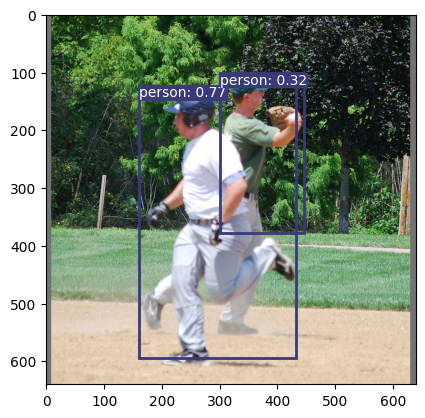

In [14]:
import time
im = "/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000872.jpg"
start = time.time()
img, _ = preprocess(im)




img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

memory = [None for _ in range(1000)] # pre allocation
memory[0] = img                      # store input image in memory at index 0
memory = walker(memory)

end = time.time()
print(f"Execution time: {end - start} seconds")

plot_image(
    img[0].permute(1, 2, 0).cpu(),
    memory[143],
    classes_ic
)
